# Get images from cameras

Reachy 2 has 2 types of camera:

- the **teleop** cameras, with a right and left cameras, located in Reachy 2’s head and used for the teleoperation
- the **depth** camera, equipped with a depth sensor, located in Reachy 2’s torso and mainly useful for manipulation tasks

Each camera can be accessed separately through reachy.cameras. Teleop cameras  have a right and left view, with the left and right sides considered from Reachy point of view, while the depth camera has a left (i.e. mono RGB) and depth view. To be able to specify the view you want to get a frame from, you will need to import CameraView:

```python
from reachy2_sdk.media.camera import CameraView
```

## Get images

First, connect to your robot.  
**Do not forget to import the CameraView!**

In [1]:
from reachy2_sdk.media.camera import CameraView
from reachy2_sdk import ReachySDK

reachy = ReachySDK(host='192.168.0.117')  # Replace with the actual IP

Local API version (1.0.21) is different from the robot's API version (1.0.19).
Some features may not work properly.
Please update the reachy2_core image on the robot to ensure compatibility, or downgrade your local reachy2_sdk package.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



Check the list of initialized cameras:

In [2]:
reachy.cameras

<CameraManager initialized_cameras=
	<Camera name="depth" stereo=False> 
	<Camera name="teleop" stereo=True> 
>

The list of initialized cameras should contain both the teleop and depth cameras.  

### Teleop cameras

To get both views of the robot teleop cameras:

In [3]:
l_frame, l_ts = reachy.cameras.teleop.get_frame(CameraView.LEFT)
r_frame, r_ts = reachy.cameras.teleop.get_frame(CameraView.RIGHT)

We can print the timestamp of each frame (in nanosecond)

In [4]:
print(f"timestamp left frame {l_ts} - timestamp right frame {r_ts}")

timestamp left frame 1772796881831724726 - timestamp right frame 1772796882097158992


Let's display the captured frame with PIL:

In [5]:
from PIL import Image

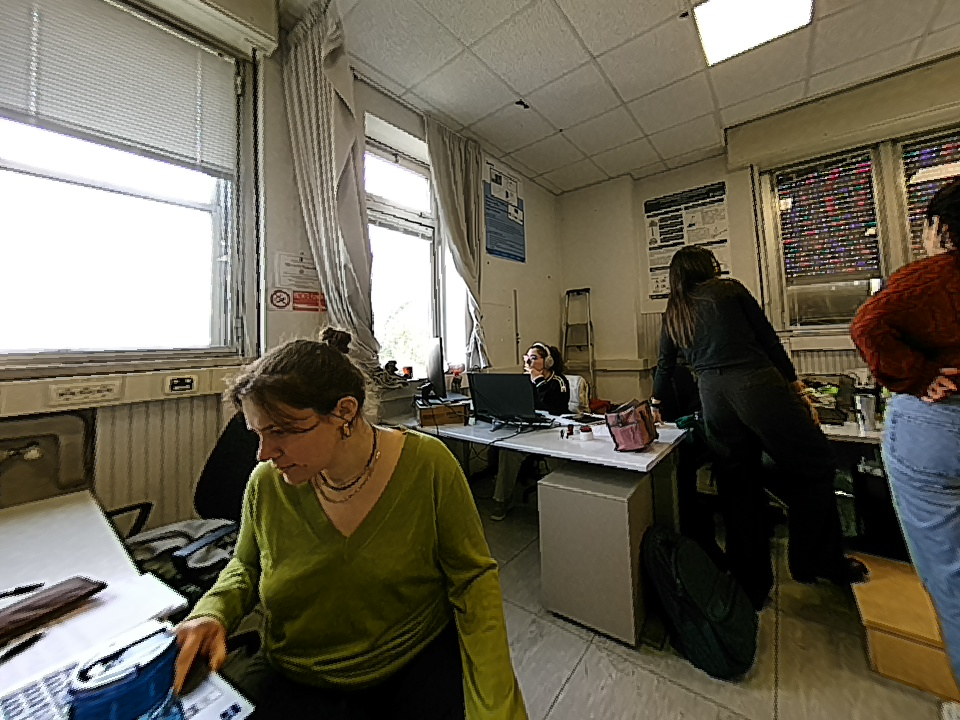

In [6]:
Image.fromarray(l_frame[:,:,::-1])

The camera parameters, as defined [here](https://docs.ros.org/en/melodic/api/sensor_msgs/html/msg/CameraInfo.html), are also available

In [7]:
height, width, distortion_model, D, K, R, P =  reachy.cameras.teleop.get_parameters(CameraView.LEFT)
print(f"height: {height}")
print(f"width: {width}")
print(f"distortion model: {distortion_model}")
print(f"distortion coefficients {D}")
print(f"instrinsic matrix {K}")
print(f"rectification matrix {R}")
print(f"projection matrix {P}")

height: 720
width: 960
distortion model: equidistant
distortion coefficients [-0.01764864  0.04212144 -0.05072903  0.01660473]
instrinsic matrix [[357.73248291   0.         500.03915405]
 [  0.         356.35748291 373.2996521 ]
 [  0.           0.           1.        ]]
rectification matrix [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
projection matrix [[355.96173096   0.         506.71005249   0.        ]
 [  0.         355.96173096 322.96740723   0.        ]
 [  0.           0.           1.           0.        ]]


### Depth camera

The depth camera works exactly the same as the teleop camera, but you have more elements captured. In fact, it's a RGBD camera, so you have both access to the RGB image and depth information.



#### RGB images

Getting RGB images from the depth camera looks the same as from the teleop one:  simply use `get_frame()`, there is only one view.

In [21]:
frame, ts = reachy.cameras.depth.get_frame()

Let's display the captured frame with PIL:

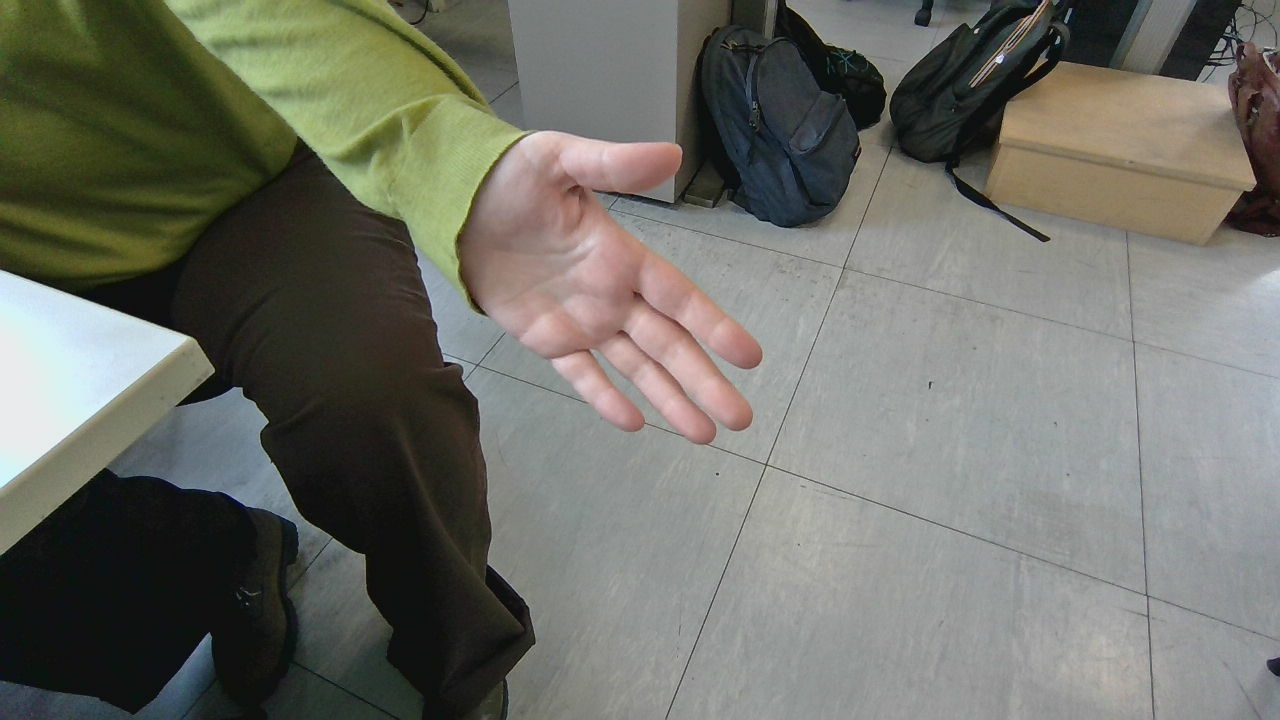

In [22]:
Image.fromarray(frame[:,:,::-1])

As for the teleop camera, parameters are also availables

In [23]:
height, width, distortion_model, D, K, R, P =  reachy.cameras.depth.get_parameters()
print(f"height: {height}")
print(f"width: {width}")
print(f"distortion model: {distortion_model}")
print(f"distortion coefficients {D}")
print(f"instrinsic matrix {K}")
print(f"rectification matrix {R}")
print(f"projection matrix {P}")

height: 720
width: 1280
distortion model: rational_polynomial
distortion coefficients [ 0.00767277 -0.04560899 -0.00037502  0.00077205  0.03057225  0.
  0.          0.        ]
instrinsic matrix [[690.13269043   0.         645.43371582]
 [  0.         690.00012207 362.46820068]
 [  0.           0.           1.        ]]
rectification matrix [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
projection matrix [[690.13269043   0.         645.43371582   0.        ]
 [  0.         690.00012207 362.46820068   0.        ]
 [  0.           0.           1.           0.        ]]


#### Depth information

The SR camera is a depth camera, you can then diplay a left or right **depth frame** using `get_depth_frame()`, but also the **depthmap** and the **disparity**.   

You first have to capture all, then you can read the frame and get the information you want:

In [34]:
depth_frame, ts = reachy.cameras.depth.get_depth_frame()
frame, ts = reachy.cameras.depth.get_frame()

Let's display the captured frame with PIL:

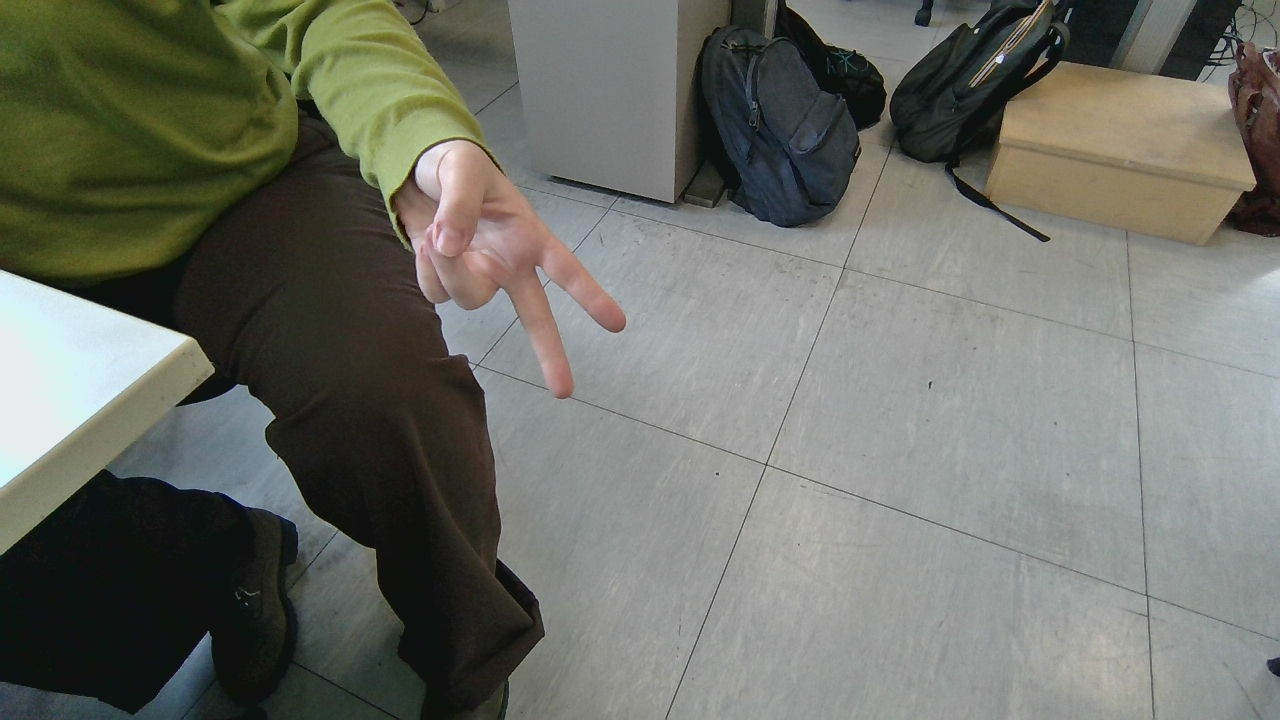

In [35]:
Image.fromarray(frame[:,:,::-1])

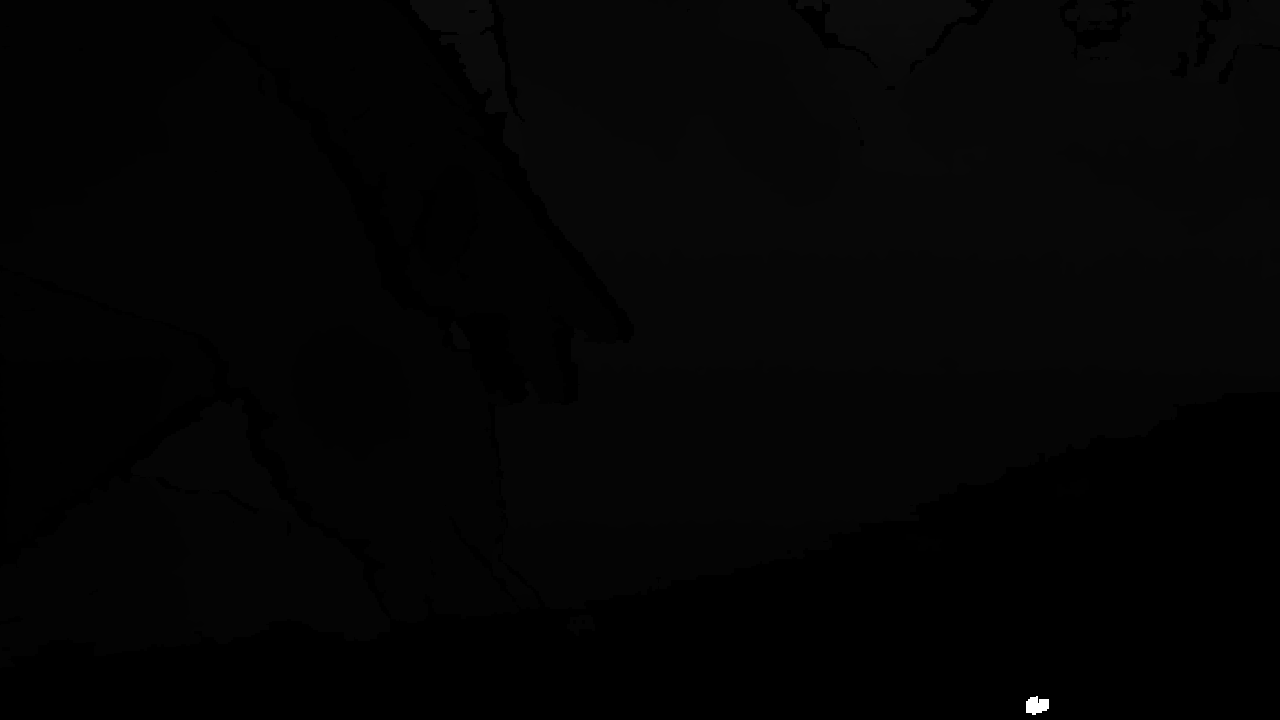

In [36]:
Image.fromarray(depth_frame[:,:])

If needed, camera parameters for the depth view are also available

In [37]:
height, width, distortion_model, D, K, R, P =  reachy.cameras.depth.get_parameters(CameraView.DEPTH)
print(f"height: {height}")
print(f"width: {width}")
print(f"distortion model: {distortion_model}")
print(f"distortion coefficients {D}")
print(f"instrinsic matrix {K}")
print(f"rectification matrix {R}")
print(f"projection matrix {P}")

height: 720
width: 1280
distortion model: rational_polynomial
distortion coefficients [0. 0. 0. 0. 0. 0. 0. 0.]
instrinsic matrix [[690.13269043   0.         645.43371582]
 [  0.         690.00012207 362.46820068]
 [  0.           0.           1.        ]]
rectification matrix [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
projection matrix [[690.13269043   0.         645.43371582   0.        ]
 [  0.         690.00012207 362.46820068   0.        ]
 [  0.           0.           1.           0.        ]]


## Live stream

Although we provide an optimal way to get the video stream, it is still possible to display what Reachy see through the SDK. It could be useful to feed a compute vision algorithm that do not need to run at high frequency.

This is demonstrated in a dedicated script : [cameras.py](cameras.py)